In [1]:
# Cell 1 — Load data and libraries
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, brier_score_loss
import shap

DATA_DIR = Path(r"C:\Users\GANESH\Desktop\weight")
hcp = pd.read_csv(DATA_DIR / "HCP_master_updated.csv")
history = pd.read_csv(DATA_DIR / "Engagement_history_improved.csv", parse_dates=["engagement_date"])
CHANNELS = ["email", "webinar", "rep_visit", "digital_ad", "phone_call"]

history = history.loc[history["channel"].isin(CHANNELS)].copy()
history["target"] = history["engagement_successful"].astype(int)
history = history.sort_values(["engagement_date", "hcp_id"]).reset_index(drop=True)
print(f"HCPs: {hcp['hcp_id'].nunique():,} | Engagements: {len(history):,}")

HCPs: 500 | Engagements: 11,039


In [2]:
# Cell 2 — Build leakage-safe features for each historical engagement
feature_rows = []
for index, event in history.iterrows():
    previous_hcp = history.iloc[:index].loc[lambda frame: frame["hcp_id"].eq(event["hcp_id"])]
    row = {"hcp_id": event["hcp_id"], "prediction_date": event["engagement_date"], "candidate_channel": event["channel"], "target": event["target"]}
    for channel in CHANNELS:
        channel_history = previous_hcp.loc[previous_hcp["channel"].eq(channel)]
        frequency = len(channel_history)
        row[f"{channel}_freq"] = frequency
        row[f"{channel}_success_rate"] = channel_history["target"].mean() if frequency else 0.0
        row[f"{channel}_recency_days"] = (event["engagement_date"] - channel_history["engagement_date"].max()).days if frequency else np.nan
        row[f"{channel}_has_history"] = int(frequency > 0)
    row["channel_diversity"] = previous_hcp["channel"].nunique()
    feature_rows.append(row)

ml_df = pd.DataFrame(feature_rows)
print("Feature rows created:", len(ml_df))
display(ml_df.head())

Feature rows created: 11039


,hcp_id,prediction_date,candidate_channel,target,email_freq,email_success_rate,email_recency_days,email_has_history,webinar_freq,webinar_success_rate,...,rep_visit_has_history,digital_ad_freq,digital_ad_success_rate,digital_ad_recency_days,digital_ad_has_history,phone_call_freq,phone_call_success_rate,phone_call_recency_days,phone_call_has_history,channel_diversity
0,108,2025-01-14 08:00:00,email,1,0,0.0,NaN,0,0,0.0,...,0,0,0.0,NaN,0,0,0.0,NaN,0,0
1,158,2025-01-14 08:00:00,digital_ad,1,0,0.0,NaN,0,0,0.0,...,0,0,0.0,NaN,0,0,0.0,NaN,0,0
2,298,2025-01-14 08:00:00,rep_visit,0,0,0.0,NaN,0,0,0.0,...,0,0,0.0,NaN,0,0,0.0,NaN,0,0
3,56,2025-01-14 09:00:00,email,1,0,0.0,NaN,0,0,0.0,...,0,0,0.0,NaN,0,0,0.0,NaN,0,0
4,99,2025-01-14 09:00:00,phone_call,0,0,0.0,NaN,0,0,0.0,...,0,0,0.0,NaN,0,0,0.0,NaN,0,0


In [3]:
# Cell 3 — Add HCP information, encode data, and create time-based splits
attribute_candidates = ["specialty", "segment", "territory", "practice_type", "account_tenure", "opt_out_flag", "channel_preference"]
attribute_columns = [column for column in attribute_candidates if column in hcp.columns]
hcp_features = hcp[["hcp_id"] + attribute_columns].drop_duplicates("hcp_id")
ml_df = ml_df.merge(hcp_features, on="hcp_id", how="left", validate="many_to_one")

ml_df = ml_df.sort_values("prediction_date").reset_index(drop=True)
train_end, validation_end = int(len(ml_df) * 0.70), int(len(ml_df) * 0.85)
ml_df["split"] = "test"
ml_df.loc[:train_end - 1, "split"] = "train"
ml_df.loc[train_end:validation_end - 1, "split"] = "validation"

exclude_columns = ["target", "hcp_id", "prediction_date", "split"]
feature_columns = [column for column in ml_df.columns if column not in exclude_columns]
X_all = pd.get_dummies(ml_df[feature_columns], dummy_na=True).replace([np.inf, -np.inf], np.nan)
y_all = ml_df["target"].astype(int)

train_mask, validation_mask, test_mask = (ml_df["split"].eq("train"), ml_df["split"].eq("validation"), ml_df["split"].eq("test"))
X_train, X_validation, X_test = X_all.loc[train_mask], X_all.loc[validation_mask], X_all.loc[test_mask]
y_train, y_validation, y_test = y_all.loc[train_mask], y_all.loc[validation_mask], y_all.loc[test_mask]
print(ml_df["split"].value_counts())

split
train         7727
validation    1656
test          1656
Name: count, dtype: int64


In [4]:
# Cell 4 — Train Logistic Regression, HistGradientBoosting, and Random Forest
models = {
    "Logistic Regression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))]),
    "HistGradientBoosting": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, random_state=42))]),
    "Random Forest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=400, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=-1, random_state=42))]),
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
HistGradientBoosting trained.
Random Forest trained.


In [5]:
# Cell 5 — Compare validation metrics and choose the best model
def evaluate_model(y_true, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y_true, probability),
        "PR_AUC": average_precision_score(y_true, probability),
        "Log_Loss": log_loss(y_true, probability, labels=[0, 1]),
        "Brier": brier_score_loss(y_true, probability),
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
    }

validation_probabilities = {name: model.predict_proba(X_validation)[:, 1] for name, model in models.items()}
validation_metrics = pd.DataFrame({name: evaluate_model(y_validation, probability) for name, probability in validation_probabilities.items()}).T
display(validation_metrics.sort_values("ROC_AUC", ascending=False).round(4))

selected_model_name = validation_metrics["ROC_AUC"].idxmax()
selected_model = models[selected_model_name]
print("Selected model by validation ROC-AUC:", selected_model_name)

,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Random Forest,0.7311,0.5493,0.5330,0.1760,0.7572,0.5986,0.3769,0.4626
HistGradientBoosting,0.7250,0.5364,0.5432,0.1780,0.7391,0.5413,0.3856,0.4504
Logistic Regression,0.6927,0.4610,0.6284,0.2189,0.6510,0.4105,0.5948,0.4858


Selected model by validation ROC-AUC: Random Forest


In [6]:
# Cell 6 — Calibrate the selected model and display final test metrics
# Calibration is fitted on training + validation data. Test data remains untouched until this cell.
X_train_validation = pd.concat([X_train, X_validation])
y_train_validation = pd.concat([y_train, y_validation])
calibrated_model = CalibratedClassifierCV(estimator=selected_model, method="sigmoid", cv=3)
calibrated_model.fit(X_train_validation, y_train_validation)

test_probability = calibrated_model.predict_proba(X_test)[:, 1]
test_metrics = pd.DataFrame([evaluate_model(y_test, test_probability)], index=[f"Calibrated {selected_model_name}"])
display(test_metrics.round(4))

,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Calibrated Random Forest,0.7409,0.5751,0.5256,0.1728,0.7615,0.7527,0.2863,0.4148


In [7]:
# Cell 7 — Build current HCP × channel candidates for recommendation
scoring_date = history["engagement_date"].max() + pd.Timedelta(days=1)
candidate_rows = []
for hcp_id in hcp["hcp_id"].drop_duplicates():
    previous_hcp = history.loc[history["hcp_id"].eq(hcp_id)]
    for candidate_channel in CHANNELS:
        row = {"hcp_id": hcp_id, "prediction_date": scoring_date, "candidate_channel": candidate_channel}
        for channel in CHANNELS:
            channel_history = previous_hcp.loc[previous_hcp["channel"].eq(channel)]
            frequency = len(channel_history)
            row[f"{channel}_freq"] = frequency
            row[f"{channel}_success_rate"] = channel_history["target"].mean() if frequency else 0.0
            row[f"{channel}_recency_days"] = (scoring_date - channel_history["engagement_date"].max()).days if frequency else np.nan
            row[f"{channel}_has_history"] = int(frequency > 0)
        row["channel_diversity"] = previous_hcp["channel"].nunique()
        candidate_rows.append(row)

candidate_features = pd.DataFrame(candidate_rows).merge(hcp_features, on="hcp_id", how="left", validate="many_to_one")
candidate_X = pd.get_dummies(candidate_features[feature_columns], dummy_na=True).reindex(columns=X_train.columns, fill_value=0).replace([np.inf, -np.inf], np.nan)
print("Scoring date:", scoring_date.date(), "| Candidate rows:", len(candidate_features))

Scoring date: 2026-01-03 | Candidate rows: 2500


In [8]:
# Cell 8 — Score and rank channel recommendations
candidate_features["success_probability"] = calibrated_model.predict_proba(candidate_X)[:, 1]
candidate_features["eligible"] = True
digital_channels = ["email", "webinar", "digital_ad"]
if "opt_out_flag" in candidate_features.columns:
    candidate_features.loc[candidate_features["opt_out_flag"].fillna(False) & candidate_features["candidate_channel"].isin(digital_channels), "eligible"] = False

ranked_candidates = candidate_features.loc[candidate_features["eligible"]].sort_values(["hcp_id", "success_probability"], ascending=[True, False]).copy()
ranked_candidates["recommendation_rank"] = ranked_candidates.groupby("hcp_id").cumcount() + 1
ranked_candidates["recommendation_tier"] = ranked_candidates["recommendation_rank"].map({1: "Primary", 2: "Secondary", 3: "Supporting"}).fillna("Other")
display(ranked_candidates[["hcp_id", "candidate_channel", "success_probability", "recommendation_tier"]].head(20))

,hcp_id,candidate_channel,success_probability,recommendation_tier
2,1,rep_visit,0.307156,Primary
1,1,webinar,0.216463,Secondary
4,1,phone_call,0.170834,Supporting
0,1,email,0.136767,Other
3,1,digital_ad,0.094462,Other
7,2,rep_visit,0.296443,Primary
6,2,webinar,0.196653,Secondary
9,2,phone_call,0.194263,Supporting
5,2,email,0.162147,Other
8,2,digital_ad,0.075679,Other


 99%|===================| 595/600 [01:48<00:00]        

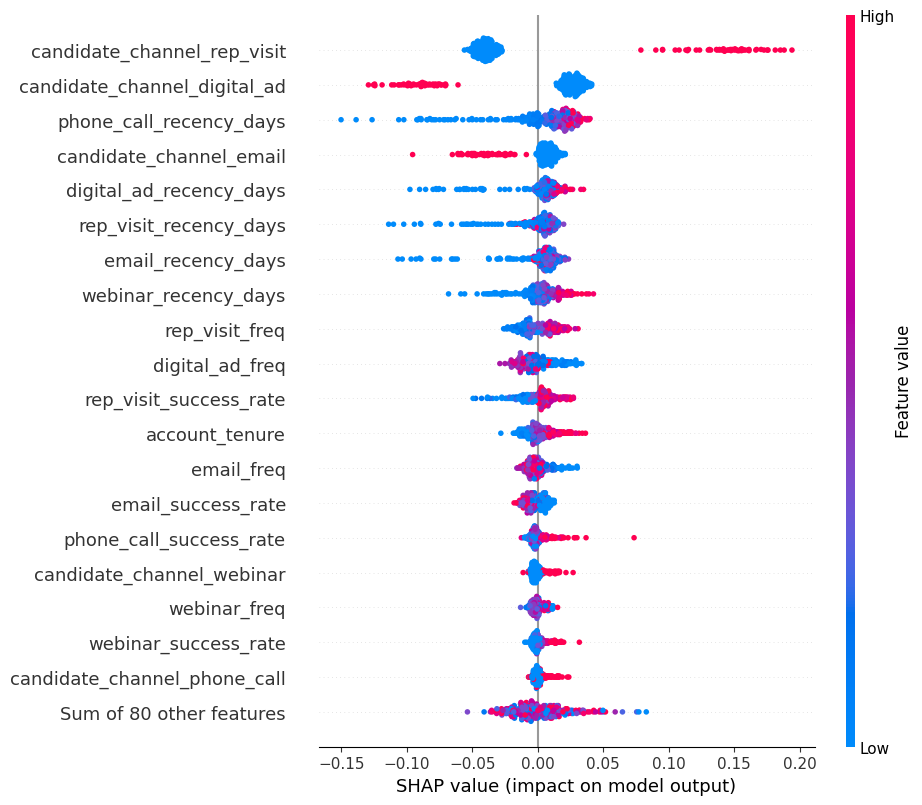

,mean_absolute_SHAP_value
candidate_channel_rep_visit,0.059060
candidate_channel_digital_ad,0.039788
phone_call_recency_days,0.023033
candidate_channel_email,0.013959
digital_ad_recency_days,0.012888
rep_visit_recency_days,0.012016
email_recency_days,0.011916
webinar_recency_days,0.010158
rep_visit_freq,0.009827
digital_ad_freq,0.009536


In [9]:
# Cell 9 — SHAP explainability for the selected base model
# SHAP explains the selected, uncalibrated model; calibration only adjusts its probability scale.
base_pipeline = selected_model
explained_model = base_pipeline.named_steps["model"]
X_shap = base_pipeline.named_steps["imputer"].transform(X_test)
if "scaler" in base_pipeline.named_steps:
    X_shap = base_pipeline.named_steps["scaler"].transform(X_shap)
X_shap = pd.DataFrame(X_shap, columns=X_train.columns, index=X_test.index)

sample_size = min(300, len(X_shap))
X_shap_sample = X_shap.sample(sample_size, random_state=42)
explainer = shap.Explainer(explained_model, X_shap_sample)
shap_values = explainer(X_shap_sample)

# Classification models can return one SHAP result for each class.  Show only
# class 1: the probability that an engagement will be successful.
if shap_values.values.ndim == 3:
    shap_values_for_success = shap_values[:, :, 1]
else:
    shap_values_for_success = shap_values

shap.plots.beeswarm(shap_values_for_success, max_display=20)

mean_abs_shap = pd.Series(np.abs(shap_values_for_success.values).mean(axis=0), index=X_shap_sample.columns).sort_values(ascending=False)
display(mean_abs_shap.head(20).rename("mean_absolute_SHAP_value").to_frame())

In [10]:
# Cell 10 — Save the final top-three recommendation scorecard
top_three = ranked_candidates.loc[ranked_candidates["recommendation_rank"] <= 3]
recommendation_scorecard = top_three.pivot(index="hcp_id", columns="recommendation_tier", values="candidate_channel").reindex(columns=["Primary", "Secondary", "Supporting"]).rename(columns={"Primary": "primary_channel", "Secondary": "secondary_channel", "Supporting": "supporting_channel"}).reset_index()
primary_probability = top_three.loc[top_three["recommendation_rank"].eq(1), ["hcp_id", "success_probability"]].rename(columns={"success_probability": "recommended_probability"})

final_recommendations = hcp.merge(recommendation_scorecard, on="hcp_id", how="left").merge(primary_probability, on="hcp_id", how="left")
final_recommendations["model_used"] = selected_model_name
output_file = "HCP_ML_Channel_Recommendations.csv"
final_recommendations.to_csv(output_file, index=False)
display(final_recommendations.head(20))
print(f"Saved: {output_file}")

,hcp_id,first_name,last_name,specialty,segment,territory,city,state,practice_type,account_tenure,opt_out_flag,channel_preference,primary_channel,secondary_channel,supporting_channel,recommended_probability,model_used
0,1,Danielle,Johnson,endocrinology,medium_value,TERR_19,Nashville,TN,hospital,0.5,False,Digital-Heavy,rep_visit,webinar,phone_call,0.307156,Random Forest
1,2,Joshua,Walker,cardiology,low_value,TERR_40,Detroit,MI,private_practice,3.3,False,In-Person-Heavy,rep_visit,webinar,phone_call,0.296443,Random Forest
2,3,Jill,Rhodes,cardiology,medium_value,TERR_21,Tucson,AZ,private_practice,0.8,False,Mixed,rep_visit,webinar,email,0.368045,Random Forest
3,4,Patricia,Miller,endocrinology,high_value,TERR_25,Arlington,TX,clinic,5.6,False,Digital-Heavy,rep_visit,email,webinar,0.222363,Random Forest
4,5,Robert,Johnson,cardiology,low_value,TERR_47,Oakland,CA,hospital,2.7,False,Mixed,rep_visit,webinar,phone_call,0.498329,Random Forest
5,6,Jeffery,Wagner,endocrinology,low_value,TERR_07,Boston,MA,clinic,1.7,False,Digital-Heavy,rep_visit,phone_call,webinar,0.708577,Random Forest
6,7,Anthony,Gonzalez,primary_care,high_value,TERR_20,Memphis,TN,private_practice,0.7,False,Mixed,rep_visit,phone_call,webinar,0.602208,Random Forest
7,8,Debra,Gardner,endocrinology,high_value,TERR_47,Sacramento,CA,private_practice,2.4,False,Mixed,rep_visit,webinar,email,0.373156,Random Forest
8,9,Jeffrey,Lawrence,primary_care,high_value,TERR_42,Houston,TX,private_practice,3.1,False,Digital-Heavy,rep_visit,email,webinar,0.244500,Random Forest
9,10,Lisa,Smith,dermatology,low_value,TERR_34,San Jose,CA,hospital,0.5,False,In-Person-Heavy,rep_visit,webinar,phone_call,0.251142,Random Forest


Saved: HCP_ML_Channel_Recommendations.csv
